# Семинар 1. Эмбеддинги: близость, аналогии, визуализация

В конспекте мы познакомились с теорией векторных представлений: прошли путь от one-hot кодирования и модели мешка слов до плотных эмбеддингов и дистрибутивной гипотезы. Теперь пришло время посмотреть, как все эти идеи работают на практике.

Главная цель семинара - не узнать новую теорию, а убедиться, что утверждения из конспекта действительно проявляются в реальных данных. Мы будем запускать эксперименты, сравнивать результаты, искать закономерности и разбираться, где привычные интуиции работают, а где перестают.

## Что мы сделаем

1. **Исследуем близость векторов.** Научимся измерять семантическое сходство с помощью косинусной близости и проверим, действительно ли похожие слова оказываются рядом в векторном пространстве.
2. **Разберем аналогии.** Посмотрим, как линейная структура эмбеддингов позволяет получать аналогии, и увидим случаи, где этот подход перестает работать.
3. **Визуализируем пространство эмбеддингов.** Спроецируем 300-мерные векторы в двумерное пространство с помощью PCA и t-SNE, чтобы увидеть, как формируются смысловые кластеры.
4. **Столкнемся с ограничениями.** Разберем практические проблемы статических эмбеддингов: многозначность слов, отсутствие редких слов в словаре (OOV) и другие причины, по которым позже появились контекстные модели.
5. **Перейдем от слов к текстам.** Построим представления целых документов и реализуем простой семантический поиск по корпусу справочных статей. Это станет мостиком к следующему семинару, посвященному классификации текстов, и к домашнему заданию.

## Зачем это нужно на практике?

Эмбеддинги - это один из базовых способов превратить текст в ту форму, с которой могут работать алгоритмы: искать похожие документы, находить информацию по смыслу, группировать тексты и использовать их как признаки для моделей. Поэтому важно не только знать, как устроено векторное представление, но и понимать, что именно оно позволяет делать и где его ограничения становятся критичными.

## Как устроено занятие

Мы будем последовательно проходить по ячейкам, запускать эксперименты и обсуждать результаты.

## Что нужно сделать перед началом

1. Откройте материалы семинара в Google Colab и держите их перед собой во время занятия. Проверьте, что Colab запускается. Если что-то не работает, лучше разобраться с этим сейчас, а не в середине семинара.
2. Задайте вопросы по материалам курса. Если что-то осталось непонятным, сейчас хороший момент это обсудить.
3. Подготовьте рабочее место. По возможности уберите телефон и другие отвлекающие устройства, чтобы во время практики можно было сосредоточиться на коде и обсуждении.
4. По возможности включите камеру. Это поможет преподавателю видеть, как группа работает, и быстрее замечать моменты, где нужна помощь.


## Комментарий преподавателю

Это первый семинар. На нем мы должны не только познакомиться со студентами, но понять ожидания и опыт.

Важно с самого начала сделать акцент на идее всей дисциплины:

>NLP - это способ решать реальные задачи, связанные с текстом: от поиска и классификации до извлечения информации и работы с большими языковыми моделями (а не просто набор готовых библиотек и моделей). Поэтому на этом курсе мы будем учиться не только использовать NLP-модели и библиотеки, но и правильно ставить задачи, анализировать данные, замечать ошибки и оценивать качество решений. Хорошее NLP-решение начинается не с выбора модели, а с понимания задачи и данных.

Перед тем, как перейти к основной части семинара, важно обсудить опыт работы студентов с текстами и ML, разобрать знакомые им задачи и посмотреть, каких практических инструментов или способов мышления может не хватать.

Вопросы для знакомства с опытом:

1. С какими текстами или языковыми данными вы уже работали?
2. Приходилось ли вам решать задачи классификации, поиска, извлечения информации или генерации текста? Что именно делали?
3. Использовали ли вы уже NLP-библиотеки или готовые языковые модели? Какие?
4. Где в вашей работе или учебных проектах сейчас возникает необходимость работать с текстом?
5. С какими проблемами при обработке текста вы уже сталкивались?
6. Что в NLP вам сейчас кажется наиболее непонятным или хотелось бы научиться делать на практике?

Вопросы, которые помогают обсудить сам подход к NLP-задачам:

1. Если вам дают набор текстов и просят найти похожие, как бы вы определили, что значит "похожие"?
2. Что нужно проверить в данных до того, как обучать модель?
3. Как понять, что выбранное решение действительно работает, а не просто дает правдоподобный результат?
4. Какие ошибки NLP-системы могут быть особенно критичными в реальной задаче?
5. Что, на ваш взгляд, отличает рабочее решение NLP-задачи от просто работающего кода?

В самом конце семинарского ноутбука находится блок "Вопросы для рефлексии" - их можно обсудить со студентами в конце занятия, если останется время.

## Блок 0. Подготовка окружения

In [ ]:
!pip install --upgrade gensim scikit-learn matplotlib pymorphy3 -qqq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 673.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 47.3 MB/s eta 0:00:00


In [ ]:
!wget -O corpus.json "https://drive.usercontent.google.com/download?id=1Y2Lv9JYZdX42f25JeOmRWOMBnJBpdQjS&export=download&confirm=t"

--2026-09-06 15:27:25--  https://drive.usercontent.google.com/download?id=1Y2Lv9JYZdX42f25JeOmRWOMBnJBpdQjS&export=download&confirm=t
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.24.132, 2404:6800:4003:c01::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.24.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6286 (6.1K) [application/octet-stream]
Saving to: ‘corpus.json’

corpus.json         100%[===================>]   6.14K  --.-KB/s    in 0s      

2026-09-06 15:27:27 (57.1 MB/s) - ‘corpus.json’ saved [6286/6286]



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.set_printoptions(precision=3, suppress=True) # чтобы векторы читались глазами
plt.rcParams["figure.dpi"] = 110

### Загружаем предобученную модель

Обучение качественных эмбеддингов с нуля требует больших вычислительных ресурсов и огромных объемов текста. Как мы обсуждали в конспекте, модели Word2Vec обучаются на миллионах контекстов, поэтому на практике почти всегда используют готовые предобученные представления.

В этом семинаре мы будем работать с русскоязычной моделью `word2vec-ruscorpora-300` - это Word2Vec, обученный на Национальном корпусе русского языка. Размерность каждого эмбеддинга составляет 300.

In [ ]:
import gensim.downloader as api

model = api.load("word2vec-ruscorpora-300")

print("Слов в словаре:", len(model.index_to_key))
print("Размерность эмбеддинга:", model.vector_size)

[==================================================] 100.0% 198.8/198.8MB downloaded
Слов в словаре: 184973
Размерность эмбеддинга: 300


### Что такое эмбеддинг?

В конспекте мы определили эмбеддинг как плотное (dense) векторное представление объекта. В отличие от one-hot векторов, такие представления имеют небольшую размерность и не просто кодируют факт существования слова, а отражают его смысл: слова, употребляющиеся в похожих контекстах, получают близкие векторы.

Но что на самом деле представляет собой такой вектор? Давайте посмотрим на него буквально. Мы загрузим эмбеддинг одного слова, увидим его 300 чисел и убедимся, что сами по себе они ничего не говорят человеку. Ценность эмбеддингов проявляется не в отдельных координатах, а в отношениях между векторами - именно благодаря им можно измерять семантическую близость, искать аналогии и выполнять поиск по смыслу.

In [ ]:
vec = model["кофе_NOUN"]
print("Тип:", type(vec).__name__)
print("Размерность:", vec.shape)
print("Первые 12 координат вектора слова 'кофе':")
print(vec[:12])

Тип: ndarray
Размерность: (300,)
Первые 12 координат вектора слова 'кофе':
[ 0.012  0.    -0.018  0.013 -0.063  0.011 -0.03  -0.047 -0.008 -0.029
  0.037 -0.038]


Сравните этот вектор с one-hot представлением, которое мы обсуждали в конспекте. Там размерность была равна размеру словаря - десятки или даже сотни тысяч координат, почти все из которых были равны нулю. Здесь же вектор состоит всего из 300 вещественных чисел, и каждое из них участвует в кодировании информации о слове.

При этом отдельные координаты не имеют самостоятельной интерпретации. Смысл распределен по всему вектору, поэтому такие представления называют **распределенными** (distributed representations).

## Блок 1. Близость векторов (эмбеддингов)

Главная идея эмбеддингов состоит в том, что **семантически похожие слова должны иметь похожие векторные представления**. Но чтобы проверить это утверждение, нужно сначала договориться, что значит "похожи" применительно к векторам.

В конспекте мы познакомились с косинусной близостью - одной из самых распространенных мер сходства эмбеддингов. Она сравнивает не длины векторов, а угол между ними:

$$\cos(\mathbf{v}, \mathbf{w}) = \frac{\mathbf{v}^{\top}\mathbf{w}}{\lVert \mathbf{v}\rVert\,\lVert \mathbf{w}\rVert}$$

Если два вектора направлены почти одинаково, значение косинусной близости близко к 1. Если направления существенно различаются - значение уменьшается. Именно поэтому косинусная близость хорошо подходит для сравнения эмбеддингов: нас интересует прежде всего их смысловое направление, а не абсолютная длина.

Сначала мы реализуем эту формулу самостоятельно - чтобы она перестала быть просто записью из конспекта, а затем сравним результат со встроенной реализацией и убедимся, что получили то же самое.

In [ ]:
def cosine(w1, w2):
    a, b = model[w1], model[w2]
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

# В этой модели векторы уже нормированы (норма каждого слова равна 1),
# поэтому обычное скалярное произведение совпадает с косинусной близостью.
first_norms = np.linalg.norm(model.vectors[:5], axis=1)
print("Нормы первых 5 слов:", first_norms)

print("cosine(кофе, чай) =", round(cosine("кофе_NOUN", "чай_NOUN"), 4))
print("gensim similarity(кофе, чай) =", round(model.similarity("кофе_NOUN", "чай_NOUN"), 4))
print("скалярное произведение =", round(float(model["кофе_NOUN"] @ model["чай_NOUN"]), 4))

Нормы первых 5 слов: [1. 1. 1. 1. 1.]
cosine(кофе, чай) = 0.7849
gensim similarity(кофе, чай) = 0.7849
скалярное произведение = 0.7849


Полученные значения совпали - значит, функция `model.similarity(...)` вычисляет ту же самую косинусную близость, которую мы разбирали в конспекте. Дальше мы будем пользоваться встроенной реализацией, чтобы не отвлекаться на технические детали.

> **Почему именно косинусная близость?** Если использовать обычное скалярное произведение, на результат будет сильно влиять длина векторов. Однако длина эмбеддинга часто отражает особенности обучения модели или частоту слова в корпусе, а не его смысл. Косинусная близость предварительно нормирует оба вектора и сравнивает только их направление, поэтому гораздо лучше отражает семантическое сходство слов.

> **Почему скалярное произведение совпало с косинусной близостью?** В этой конкретной модели векторы загружены уже нормированными (см. проверку норм выше): длина каждого слова равна 1. Поэтому `a @ b` совпадает с `cos(a, b)`. Важно понимать: такая нормализация - свойство именно этих векторов, а не гарантия Gensim. При загрузке другой модели нормы могут отличаться от 1, поэтому прежде чем заменять косинусную близость скалярным произведением, стоит явно проверить нормы векторов.


### Проверяем пример из конспекта: чай / кофе / стол

Помните пример: `tea` и `coffee` должны стоять ближе друг к другу, чем к `table`? Проверим его для русского.

In [ ]:
pairs = [("чай_NOUN", "кофе_NOUN"),
         ("чай_NOUN", "стол_NOUN"),
         ("кофе_NOUN", "стол_NOUN")]
for a, b in pairs:
    print(f"{a.split('_')[0]} - {b.split('_')[0]}: {model.similarity(a, b):.3f}")

чай - кофе: 0.785
чай - стол: 0.399
кофе - стол: 0.367


"Чай - кофе" заметно ближе, чем оба к "столу". Именно это свойство отсутствовало у one-hot: там любые два разных слова были одинаково "далеки" (косинус ровно 0). Плотные векторы это чинят.

### Ближайшие соседи: `most_similar`

Вычислять косинусную близость для отдельных пар слов полезно, но на практике чаще возникает другой вопрос: какие слова наиболее похожи на данное?

Именно для этого в `gensim` есть метод `most_similar`. Он вычисляет косинусную близость между заданным словом и всеми словами словаря, сортирует результаты по убыванию сходства и возвращает несколько ближайших соседей.

Это один из самых простых способов заглянуть внутрь эмбеддингов и проверить, насколько хорошо модель уловила семантические связи. Если все работает как ожидается, рядом окажутся слова, которые употребляются в похожих контекстах и имеют близкое значение - хотя иногда среди соседей встречаются и неожиданные результаты, о причинах которых мы поговорим позже.

In [ ]:
for w, s in model.most_similar("кофе_NOUN", topn=8):
    print(f"{s} - {w.split('_')[0]}")

0.7849310040473938 - чай
0.718063235282898 - чашка
0.6924780011177063 - кофей
0.6689926385879517 - каппучино
0.6658537983894348 - коньяк
0.6573574542999268 - какао
0.6461552977561951 - эспрессо
0.6439230442047119 - стакан


**На подумать**

Прежде чем запускать следующую ячейку, предположите, какие слова окажутся ближайшими к `доставка_NOUN` в контексте интернет-магазина. Потом проверьте. Совпало ли с интуицией? Что удивило?

In [ ]:
for w, s in model.most_similar("доставка_NOUN", topn=8):
    print(f"{s} - {w.split('_')[0]}")

0.6826704740524292 - перевозка
0.6332200169563293 - отправка
0.6159632205963135 - транспортировка
0.5752121806144714 - доставляться
0.5729721188545227 - переотправка
0.5527556538581848 - погрузка::выгрузка
0.5518833994865417 - dhl
0.5502382516860962 - фулфилмент


### Дистрибутивная близость ≠ синонимия

Один из выводов конспекта заключался в том, что **близость эмбеддингов не означает синонимичность слов**. Модель обучается не по словарным определениям, а по контекстам, в которых встречаются слова.

Из-за этого слова, которые часто употребляются в одинаковых конструкциях, могут получить очень похожие векторы - даже если их значения противоположны. Например, слова **"хороший"** и **"плохой"** нередко появляются в схожих контекстах: *хороший фильм* / *плохой фильм*, *хорошая идея* / *плохая идея*, *хорошая погода* / *плохая погода*. Для модели эти слова во многом оказываются "взаимозаменяемыми" с точки зрения окружения.

Именно поэтому эмбеддинги отражают прежде всего **дистрибутивную близость** - сходство контекстов, а не логические отношения между словами. Давайте проверим это утверждение на практике и посмотрим, насколько близкими окажутся векторы слов с противоположным смыслом.

In [ ]:
antonyms = [("хороший_ADJ", "плохой_ADJ"),
            ("горячий_ADJ", "холодный_ADJ"),
            ("большой_ADJ", "маленький_ADJ"),
            ("день_NOUN",   "ночь_NOUN")]
for a, b in antonyms:
    print(f"{a.split('_')[0]} — {b.split('_')[0]}: {model.similarity(a, b):.3f}")

хороший — плохой: 0.746
горячий — холодный: 0.614
большой — маленький: 0.532
день — ночь: 0.590


Получается неожиданный результат: антонимы нередко оказываются очень близки в пространстве эмбеддингов - иногда даже ближе друг к другу, чем слова, которые человек интуитивно назвал бы "похожими". Это не ошибка модели, а закономерное следствие того, как обучаются статические эмбеддинги. Они отражают статистику совместного употребления слов и их роль в контекстах, а не логические отношения между их значениями.

**На подумать**

Представьте, что вы строите поиск по отзывам и хотите находить отзывы с похожей тональностью. Если эмбеддинги хорошо отражают контекст, слова "хороший" и "плохой" могут оказаться близкими по смыслу, хотя их тональность противоположна. Это помогает вам или мешает?

А теперь другая задача: вы хотите найти слова той же тематики - например, "кофе", "чай", "лимонад" или "ноутбук", "смартфон", "планшет". Здесь такая близость, наоборот, оказывается полезной.

Почему один и тот же инструмент в одной задаче помогает, а в другой мешает? Что именно должно отражать пространство эмбеддингов, чтобы поиск работал хорошо?

**Возможный ход рассуждений**

Эмбеддинги отражают семантическую близость в контексте, но семантическая близость не всегда означает одинаковую тональность. Поэтому близкие в векторном пространстве слова "хороший" и "плохой" могут быть полезны для тематической группировки, но мешать, если нам важно различать "хвалит" и "ругает".

Отсюда важный вывод: близость эмбеддингов не является универсальной мерой сходства - ее полезность зависит от того, какое именно сходство нужно измерять.

Если задача - определить тональность, одних статических эмбеддингов обычно недостаточно: можно обучить классификатор поверх эмбеддингов на размеченных данных (это будет рассмотрено далее в курсе) или использовать контекстные модели, специально учитывающие контекст слова.

## Блок 2. Аналогии

Одно из самых известных свойств эмбеддингов, которое мы обсуждали в конспекте, - линейная структура векторного пространства. Оказывается, некоторые отношения между словами можно выразить с помощью простых арифметических операций над их векторами.

Классический пример:

$$\mathbf{v}_{\text{король}} - \mathbf{v}_{\text{мужчина}} + \mathbf{v}_{\text{женщина}} \approx \mathbf{v}_{\text{королева}}$$

Интуитивно это можно понимать так: вектор "король - мужчина" отражает признаки, связанные с понятием "монарх", но без привязки к мужскому полу. Если затем добавить вектор "женщина", результат должен оказаться рядом с вектором слова "королева".

Конечно, модель не знает понятий "пол" или "монархия" в явном виде. Она лишь обучалась предсказывать слова по их контекстам. Тем интереснее, что такие отношения самопроизвольно возникают в пространстве эмбеддингов.

Сейчас мы проверим, насколько хорошо это работает на нашей модели. Для этого воспользуемся методом `most_similar()`, который позволяет искать слова, близкие к результату арифметических операций над векторами (`positive=[...]`, `negative=[...]`).

In [ ]:
def analogy(positive, negative, topn=3):
    res = model.most_similar(positive=positive, negative=negative, topn=topn)
    return [(w.split("_")[0], round(s, 3)) for w, s in res]

# король - мужчина + женщина = ?
analogy(positive=["король_NOUN", "женщина_NOUN"], negative=["мужчина_NOUN"])

[('королева', 0.731), ('герцог', 0.65), ('принцесса', 0.627)]

В нашем примере первым действительно оказывается "королева". При этом модель никто специально не обучал понятиям "мужчина", "женщина" или "монарх". Она лишь анализировала, в каких контекстах встречаются слова. Тем не менее отношение между ними проявилось в геометрии векторного пространства: векторный переход от "мужчины" к "женщине" оказался похож на переход от "короля" к "королеве".

Важно понимать, что это не "логический вывод" модели, а статистическая закономерность, возникшая в результате обучения на большом корпусе текстов.

Конечно, аналогии работают не всегда. Но многие распространенные отношения - родственные связи, формы слов, столицы и страны, профессии, степени сравнения и другие - действительно оказываются представлены в пространстве эмбеддингов почти линейно.

Давайте проверим еще несколько примеров и посмотрим, насколько универсально это свойство.

In [ ]:
print("Столица -> страна (Берлин - Германия + Франция):", analogy(["берлин_NOUN", "франция_NOUN"], ["германия_NOUN"]))
print("Столица -> страна (Токио - Япония + Китай):", analogy(["токио_NOUN", "китай_NOUN"], ["япония_NOUN"]))
print("Родство и пол (сын - мужчина + женщина):", analogy(["сын_NOUN", "женщина_NOUN"], ["мужчина_NOUN"]))
print("Мужской/женский род профессии (актер - мужчина + женщина):", analogy(["актер_NOUN", "женщина_NOUN"], ["мужчина_NOUN"]))

Столица -> страна (Берлин - Германия + Франция): [('париж', 0.849), ('лондон', 0.716), ('брюссель', 0.655)]
Столица -> страна (Токио - Япония + Китай): [('пекин', 0.733), ('шанхай', 0.658), ('китайский', 0.634)]
Родство и пол (сын - мужчина + женщина): [('дочь', 0.781), ('мать', 0.665), ('внук', 0.639)]
Мужской/женский род профессии (актер - мужчина + женщина): [('актриса', 0.788), ('артист', 0.735), ('режиссер', 0.713)]


**Мини-задание**

Придумайте и проверьте свою аналогию вида `A - B + C ~ ?`. Например, "Москва относится к России, как Берлин к ...?". Не забудьте добавить `_NOUN` / `_ADJ`. Что у вас получилось?

In [ ]:
# Ваш код

### Где аналогии ломаются: границы применимости

В конспекте мы уже отмечали, что аналогии с эмбеддингами работают не всегда: результат зависит от типа отношений между словами и от того, на каких текстах обучалась модель. Поэтому удачная аналогия еще не означает, что модель действительно "понимает" язык.

Разберем примеры, где ожидание от аналогии расходится с тем, что на самом деле показывает векторное пространство.


In [ ]:
# "день так относится к солнцу, как ночь к ...?" - ожидаем "луна"
print("солнце - день + ночь:", analogy(["солнце_NOUN", "ночь_NOUN"], ["день_NOUN"]))

# "рыба живет в воде, птица - в ...?" - ожидаем "небо" / "воздух"
print("вода - рыба + птица:", analogy(["вода_NOUN", "птица_NOUN"], ["рыба_NOUN"]))


солнце - день + ночь: [('светить', 0.595), ('луна', 0.579), ('солнечный', 0.561)]
вода - рыба + птица: [('влага', 0.498), ('воздух', 0.473), ('дождевой', 0.47)]


Линейные закономерности в пространстве эмбеддингов действительно есть, но они работают лишь для некоторых типов отношений и дают приближенную, а не идеальную точность. Поэтому полагаться на аналогии как на проявление "интеллекта модели" нельзя. Скорее, это удобный способ оценивать качество эмбеддингов - intrinsic-оценка, о которой мы говорили.


### Эмбеддинги наследуют предвзятость данных

В конспекте был отдельный пункт про смещения (bias): эмбеддинги наследуют статистические закономерности корпуса и могут воспроизводить социальные стереотипы. Например, профессии могут оказываться ближе к словам, связанным с определенным полом.

Проверим это количественно: для каждой профессии сравним ее близость к "женщине" и к "мужчине". Разность `cos(проф, женщина) - cos(проф, мужчина)` будем использовать как показатель "гендерного наклона".


In [ ]:
def gender_lean(prof):
    t = prof + "_NOUN"
    return model.similarity(t, "женщина_NOUN") - model.similarity(t, "мужчина_NOUN")

profs = ["няня", "медсестра", "врач", "учитель", "инженер", "программист", "бухгалтер", "директор", "пилот"]
for p in sorted(profs, key=gender_lean, reverse=True):
    lean = gender_lean(p)
    side = "ближе к 'женщина'" if lean > 0 else "ближе к 'мужчина'"
    print(f"{p:12} {lean:+.3f} - {side}")

няня         +0.132 - ближе к 'женщина'
медсестра    +0.079 - ближе к 'женщина'
врач         +0.061 - ближе к 'женщина'
инженер      +0.021 - ближе к 'женщина'
учитель      +0.009 - ближе к 'женщина'
программист  -0.008 - ближе к 'мужчина'
директор     -0.043 - ближе к 'мужчина'
бухгалтер    -0.045 - ближе к 'мужчина'
пилот        -0.053 - ближе к 'мужчина'


"Няня", "медсестра", "врач" оказываются ближе к "женщине", а "пилот", "директор", "программист" - к "мужчине". Это отражение статистических закономерностей в текстах, на которых модель обучалась.




**На подумать**

- Вы используете такие эмбеддинги как признаки в системе отбора резюме. Какой конкретный вред может возникнуть?
- Что изменится, если поменять корпус - например, тексты 2000-х на современные? А если задача чисто тематическая, например роутинг обращений в поддержку, будет ли такой bias так же критичен?

**Возможный ход рассуждения**

Если эмбеддинги используются при отборе резюме, гендерный bias может привести к систематической дискриминации: кандидаты с похожим опытом могут получать разные оценки из-за косвенной связи профессии с полом. В результате модель способна воспроизводить уже существующее неравенство из обучающих данных.

Если изменить корпус, изменится и статистическая структура пространства. Например, в современных текстах некоторые профессии могут быть представлены более гендерно нейтрально, поэтому соответствующий bias может ослабнуть, усилиться или изменить направление. Это показывает, что bias эмбеддингов зависит не только от архитектуры модели, но и от данных, на которых она обучалась.

В тематической задаче, например, при роутинге обращений в поддержку, такой bias может быть менее критичен, если пол не влияет на итоговое решение и не используется как критерий доступа к важному ресурсу. Но это не означает, что bias автоматически безопасен: если гендерные ассоциации влияют на качество маршрутизации или приводят к разному обслуживанию пользователей, проблема все равно возникает.

Главный вывод - наличие bias само по себе еще не говорит, насколько он опасен, важно смотреть, как именно эмбеддинги используются и на какое решение они влияют.

## Блок 3. Визуализация

До этого момента мы сравнивали эмбеддинги попарно: вычисляли косинусную близость, искали ближайших соседей и проверяли аналогии. Но как выглядит все пространство эмбеддингов целиком?

Проблема в том, что каждый вектор имеет 300 измерений, а человек способен воспринимать только два или три. Поэтому нам понадобится метод понижения размерности - с такими методами вы, возможно, уже знакомы по курсу машинного обучения.

Мы спроецируем эмбеддинги в двумерное пространство и посмотрим, сохранится ли их структура. Если эмбеддинги действительно отражают смысл слов, то после такой проекции слова одной тематики должны оказаться недалеко друг от друга и образовать заметные кластеры.

Для наглядности возьмем несколько заранее подготовленных тематических групп слов. Это позволит сравнить получившуюся картину с тем, что мы ожидаем увидеть, и оценить, насколько хорошо пространство эмбеддингов сохраняет семантические связи.

In [ ]:
groups = {
    "фрукты": ["яблоко", "банан", "апельсин", "виноград", "груша", "лимон"],
    "животные": ["собака", "кошка", "лошадь", "корова", "тигр", "заяц"],
    "страны": ["франция", "германия", "италия", "япония", "россия", "бразилия"],
    "родство": ["мать", "отец", "сын", "дочь", "брат", "сестра"],
    "транспорт": ["автомобиль", "поезд", "самолет", "корабль", "велосипед", "автобус"]
}

words, labels = [], []
for g, ws in groups.items():
    for w in ws:
        words.append(w)
        labels.append(g)

def to_token(w):
    for pos in ("_NOUN", "_ADJ"):
        if w + pos in model.key_to_index:
            return w + pos
    return None

tokens = [to_token(w) for w in words]
assert all(t is not None for t in tokens), [w for w, t in zip(words, tokens) if t is None]
X = np.stack([model[t] for t in tokens])
print("Матрица векторов:", X.shape) # (кол-во слов, 300)

Матрица векторов: (30, 300)


### Линейная проекция: PCA

Начнем с **метода главных компонент (PCA)** - одного из самых простых и наиболее известных методов понижения размерности.

Идея PCA заключается в том, чтобы найти новые оси координат, вдоль которых данные имеют наибольший разброс (дисперсию). Первая главная компонента объясняет максимально возможную долю изменчивости данных, вторая - максимально возможную среди оставшейся информации и при этом ортогональна первой, и так далее.

Для визуализации нам достаточно оставить **две первые главные компоненты**. Это позволит заменить 300-мерные эмбеддинги двумерными точками и посмотреть, сохраняются ли в таком представлении смысловые группы слов.

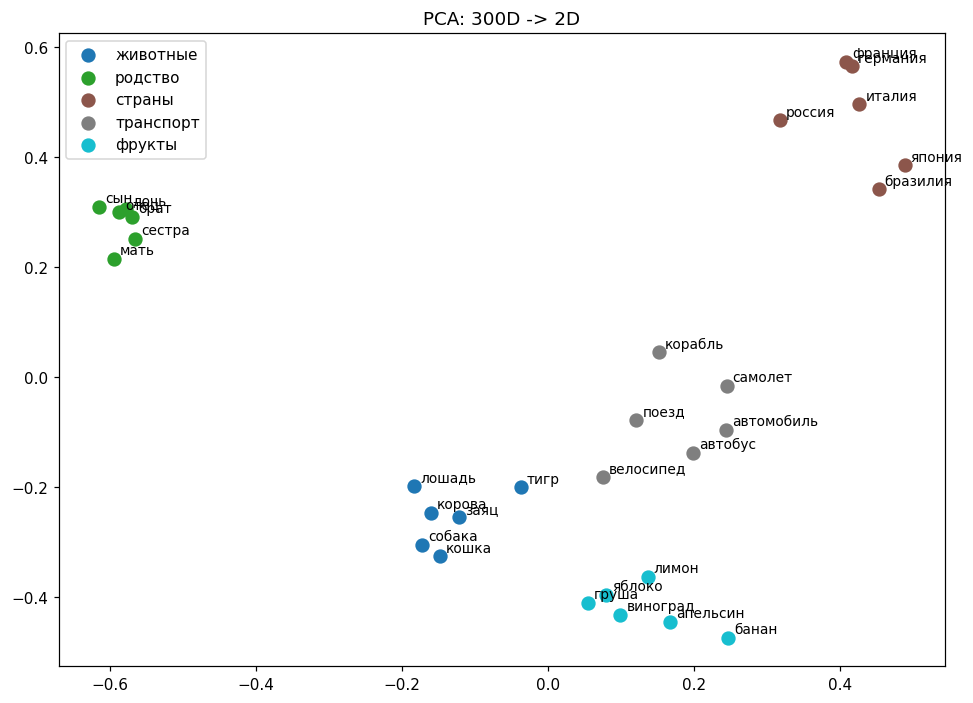

In [ ]:
from sklearn.decomposition import PCA

pca_xy = PCA(n_components=2, random_state=0).fit_transform(X)

def plot_2d(xy, words, labels, title):
    plt.figure(figsize=(9, 6.5))
    uniq = sorted(set(labels))
    cmap = plt.cm.tab10(np.linspace(0, 1, len(uniq)))
    color = {g: cmap[i] for i, g in enumerate(uniq)}
    for g in uniq:
        idx = [i for i, l in enumerate(labels) if l == g]
        plt.scatter(xy[idx, 0], xy[idx, 1], color=color[g], label=g, s=70)
    for i, w in enumerate(words):
        plt.annotate(w, (xy[i, 0], xy[i, 1]), fontsize=9, xytext=(4, 3), textcoords="offset points")
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_2d(pca_xy, words, labels, "PCA: 300D -> 2D")

После проекции видно, что слова одной тематики действительно оказываются рядом, а разные темы образуют отдельные группы. При этом мы не сообщали алгоритму, какие слова относятся к фруктам, странам или животным. Кластеры возникли сами, потому что эмбеддинги уже содержали информацию о семантической близости слов.

Это еще одно подтверждение **дистрибутивной гипотезы**: слова, употребляющиеся в похожих контекстах, получают похожие векторные представления.

### Нелинейная проекция: t-SNE

У PCA есть важное ограничение: это **линейный** метод. Он хорошо передает общую структуру данных, но не всегда сохраняет ближайшее окружение каждой точки.

Если цель - как можно лучше сохранить локальную структуру пространства, часто используют алгоритм **t-SNE**. В отличие от PCA, он выполняет **нелинейное** понижение размерности и старается разместить на плоскости так, чтобы ближайшие соседи в исходном пространстве остались ближайшими и после проекции.

Давайте применим t-SNE к тем же самым эмбеддингам и сравним результат с PCA. Так мы увидим, какие особенности структуры пространства лучше сохраняет каждый из методов.

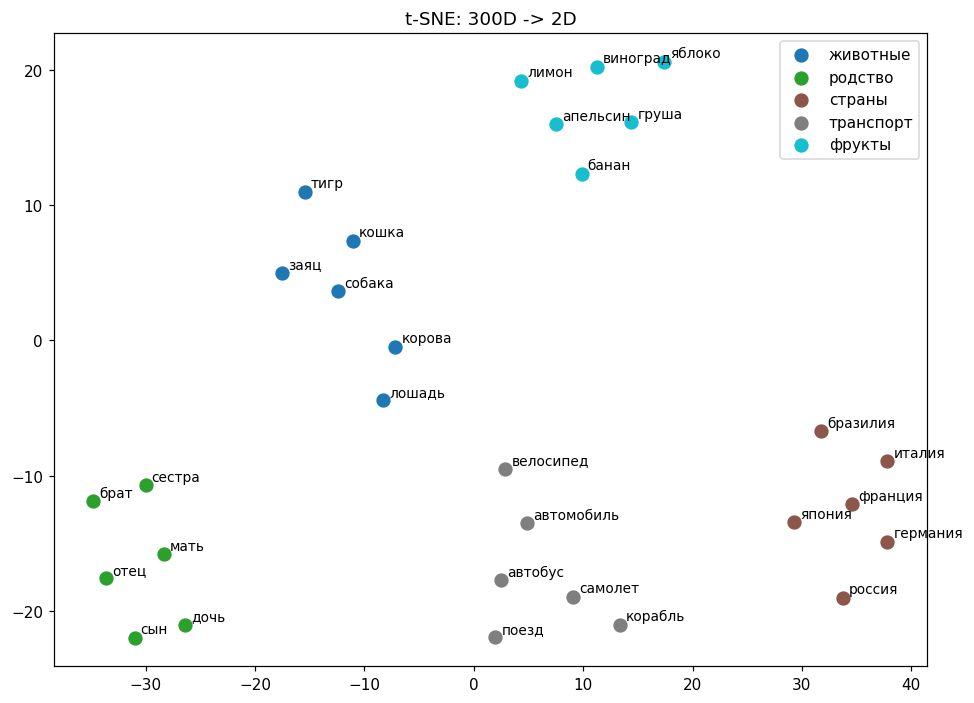

In [ ]:
from sklearn.manifold import TSNE

tsne_xy = TSNE(n_components=2, perplexity=8, init="pca", learning_rate="auto", random_state=0).fit_transform(X)
plot_2d(tsne_xy, words, labels, "t-SNE: 300D -> 2D")

**На подумать**

- Где кластеры выглядят плотнее и лучше разделены - на PCA или t-SNE? Почему?
- На t-SNE расстояния **между кластерами** и их размеры часто нельзя интерпретировать напрямую. Можно ли тогда по такой картинке сказать: "страны дальше от транспорта, чем от животных"?
- Какой метод вы выберете, чтобы (а) быстро получить представление о структуре данных, (б) показать соседство объектов на наглядной иллюстрации?

**Возможный ход рассуждения**

PCA и t-SNE решают похожую задачу - переводят многомерные данные в 2D, но делают это по-разному.

На t-SNE кластеры могут выглядеть более четкими, потому что метод специально старается сохранить локальное соседство: близкие объекты остаются близкими, а разные группы визуально разделяются. PCA ищет направления максимальной дисперсии и не пытается специально "развести" кластеры, поэтому группы могут выглядеть менее очевидно.

Но из этого не следует, что t-SNE лучше сохраняет глобальную структуру. Расстояния между отдельными кластерами, их размеры и промежутки между ними могут зависеть от параметров визуализации. Поэтому по t-SNE нельзя делать вывод вроде "страны ближе к транспорту, чем к животным" - для такого сравнения нужно вернуться к исходному пространству и посчитать косинусное сходство.

Для быстрого первичного анализа структуры данных можно начать с PCA: он проще интерпретируется, работает быстро и дает представление о направлениях наибольшей вариативности. Если же нужно показать локальное соседство объектов в 2D, t-SNE может дать более наглядную картину.

Главная мысль: 2D-визуализация помогает увидеть закономерности, но не заменяет количественную оценку. Если нужно ответить на вопрос "насколько объекты похожи", считаем метрику в исходном пространстве, а не измеряем расстояния на картинке.


**Вывод**

Визуализация - **инструмент для формирования интуиции, а не для измерений**. Численные сравнения выполняем в исходном 300-мерном пространстве, например, с помощью косинусного сходства, а 2D-визуализацию используем, чтобы заметить кластеры, локальных соседей, выбросы и возможные артефакты.


## Блок 4. Ограничения статических эмбеддингов на практике

В конспекте перечислялись ограничения статических эмбеддингов. Два из них удобно показать вживую - именно они позже мотивируют переход к контекстным моделям и BERT.

### Ограничение 1. Статичность и многозначность

Word2Vec сопоставляет слову **один** вектор - независимо от смысла в конкретном предложении. В конспекте был пример - слово *mouse* (животное и компьютерное устройство). Посмотрим на русские многозначные слова: у "мыши" есть значения "животное" и "компьютерная мышь", у "лука" - "растение" и "оружие".

In [ ]:
for w in ["мышь_NOUN", "лук_NOUN"]:
    print(w.split("_")[0], "->", [x.split("_")[0] for x, _ in model.most_similar(w, topn=8)])

мышь -> ['крыса', 'инокулировать', 'мышиный', 'внутрибрюшинный', 'интрацеребральный', 'аэрогенный::заражение', 'мышонок', 'balb::c']
лук -> ['морковь', 'чеснок', 'лука', 'порей', 'репчатый::лук', 'спассеровать', 'укроп', 'спассеровывать']


У "мыши" в соседях - крыса, мышонок и биологические термины: победило значение "животное", а "компьютерное" почти не видно. У "лука" - морковь, чеснок, порей: осталось только "растение", а "оружие/стрельба" пропало. Модель хранит **один усредненный вектор на все смыслы**, поэтому редкое значение размывается.

### Ограничение 2. Слова вне словаря (OOV)

Словарь фиксируется при обучении. Слова, которых там не было (новые термины, опечатки, редкие имена), представить нельзя - при обращении получим ошибку.

In [ ]:
for w in ["эмбеддинг_NOUN", "криптовалюта_NOUN", "смузи_NOUN"]:
    print(f"'{w.split('_')[0]}' есть в словаре? {w in model.key_to_index}")

# попытка достать вектор несуществующего слова -> KeyError
try:
    model["эмбеддинг_NOUN"]
except KeyError as e:
    print("KeyError:", e)

'эмбеддинг' есть в словаре? False
'криптовалюта' есть в словаре? False
'смузи' есть в словаре? False
KeyError: "Key 'эмбеддинг_NOUN' not present"


Даже слова "эмбеддинг" в словаре модели нет (оно новее корпуса). В конспекте упоминалось частичное решение - **FastText**: он представляет слово через его символьные n-граммы (подстроки), поэтому может собрать вектор даже для незнакомого слова из знакомых кусочков. Обучим крошечный FastText на игрушечном корпусе и проверим OOV.

In [ ]:
from gensim.models import FastText

toy = [
    "кот сидит на коврике".split(),
    "собака гонится за котом".split(),
    "коты и собаки это животные".split(),
    "котенок играет с котиком".split(),
    "щенок и щенки любят играть".split()
] * 60

ft = FastText(toy, vector_size=32, window=3, min_count=1, min_n=2, max_n=4, epochs=20).wv

for w in ["котята", "котэ", "собакен"]: # ни одного НЕТ в игрушечном корпусе
    print(f"'{w}' нет в словаре, но вектор собрался: {ft[w].shape}")

print("Близость котенок ~ котята:", round(float(ft.similarity("котенок", "котята")), 3))

'котята' нет в словаре, но вектор собрался: (32,)
'котэ' нет в словаре, но вектор собрался: (32,)
'собакен' нет в словаре, но вектор собрался: (32,)
Близость котенок ~ котята: 0.973


FastText выдал осмысленный вектор для слов, которых **не было** в обучении, и "котенок" оказался близок к "котята" - потому что у них общие подстроки (`кот`, `оте`, ...). Это и есть смягчение проблемы OOV и устойчивость к морфологии.

**На подумать**

Для какого из двух ограничений (многозначность vs OOV) FastText - решение, а для какого - нет?

**Возможный ход рассуждения**

FastText решает проблему OOV, но не проблему многозначности.

Для OOV FastText полезен потому, что строит представление слова из символьных n-грамм. Поэтому даже если конкретного слова не было в обучающем корпусе, модель может собрать для него вектор из знакомых частей слова.

А вот многозначность FastText не устраняет. Для слова с несколькими значениями он по-прежнему создает один общий вектор, который смешивает разные контексты. Например, слово "лук" может означать овощ и оружие, но FastText не создает отдельные векторы для этих значений.


## Блок 5. От слов к текстам: работаем с корпусом

До сих пор мы работали на уровне **отдельных слов**. Но в реальных задачах объектом анализа обычно становится **целый текст**: обращение в поддержку, отзыв, статья или справочный документ.

В конспекте мы разделяли эти уровни: **BoW/TF-IDF** описывают документ как набор признаков, а **Word2Vec** строит представления отдельных слов. Теперь объединим эти подходы и посмотрим, как работать с небольшим корпусом текстов.

Наш корпус `corpus.json` - это база знаний интернет-магазина: короткие справочные абзацы по темам "Доставка", "Возврат", "Гарантия" и т.д.

Практическая задача - **семантический поиск**: по запросу пользователя найти в корпусе наиболее релевантный абзац. Решим эту задачу двумя способами, сравним результаты и посмотрим, в чем сильные и слабые стороны каждого подхода.


In [ ]:
import json, os

path = "corpus.json"
corpus = json.load(open(path, "r", encoding="utf-8"))
texts  = [c["text"] for c in corpus]
topics = [c["doc"] for c in corpus]

print("Абзацев:", len(corpus))
print("Тем:", len(set(topics)))
print("Темы:", sorted(set(topics)))
print("Пример абзаца [0]:", texts[0])

Абзацев: 24
Тем: 8
Темы: ['Аккаунт', 'Акции', 'Возврат товара', 'Гарантия', 'Доставка', 'Оплата', 'Поддержка', 'Программа лояльности']
Пример абзаца [0]: Вернуть товар можно в течение 14 дней с даты получения, если он не был в использовании и сохранён товарный вид. Новый регламент возврата действует с 1 марта 2026 года; к заказам, оформленным раньше, применяются прежние правила.


### Общая подготовка: лемматизация

Оба подхода - и TF-IDF, и усредненные эмбеддинги - будем кормить одним и тем же текстом после одинаковой лемматизации и нормализации. Так сравнение будет честным: если один метод окажется лучше, причина будет в самом подходе, а не в разной предобработке текста.

Чтобы получить из текста токены в формате `лемма_POS`, как в словаре модели, приведем слова к начальной форме и определим их часть речи с помощью лемматизатора **pymorphy3**.

In [ ]:
import re
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

# соответствие тегов pymorphy -> UD-тегов, которые использует модель
POS_MAP = {"NOUN": "NOUN", "ADJF": "ADJ", "ADJS": "ADJ", "VERB": "VERB",
           "INFN": "VERB", "ADVB": "ADV", "NPRO": "PRON",
           "PRTF": "VERB", "PRTS": "VERB", "GRND": "VERB", "NUMR": "NUM"}

def normalize(word):
    # модель хранит почти все слова через "е", поэтому приводим "ё" -> "е"
    return word.replace("ё", "е").replace("Ё", "Е")

def to_tokens(text):
    # текст -> список токенов вида "лемма_POS", как в модели
    out = []
    for w in re.findall(r"[А-Яа-яЁёA-Za-z]+", text.lower()):
        p = morph.parse(w)[0]
        pos = POS_MAP.get(p.tag.POS)
        if pos:
            out.append(normalize(p.normal_form) + "_" + pos)
    return out

def to_text(text):
    # те же леммы, но без тегов части речи - для TF-IDF
    return " ".join(t.split("_")[0] for t in to_tokens(text))

print(to_tokens("во сколько отвечает служба помощи"))

['сколько_ADV', 'отвечать_VERB', 'служба_NOUN', 'помощь_NOUN']


### Способ 1. TF-IDF - представление документа

Первый подход - знакомый нам по конспекту: представим каждый абзац в виде **TF-IDF-вектора**, где вес слова зависит от его частоты в документе и редкости во всем корпусе. Затем будем искать наиболее релевантный абзац по **косинусной близости**.

Это простой, быстрый и хорошо интерпретируемый **бейзлайн**: можно понять, какие слова повлияли на результат поиска и почему конкретный документ оказался похож на запрос.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

texts_lemm = [to_text(t) for t in texts] # та же лемматизация, что и для эмбеддингов
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(texts_lemm) # (24 абзаца, размер словаря)
print("TF-IDF матрица 'документ-термин':", X_tfidf.shape)

def search_tfidf(query, k=3):
    q = tfidf.transform([to_text(query)])
    sims = cosine_similarity(q, X_tfidf)[0]
    order = np.argsort(-sims)[:k]
    return [(sims[i], topics[i], texts[i]) for i in order]

for s, topic, t in search_tfidf("сколько стоит курьерская доставка"):
    print(f"{s:.3f}   [{topic}]   {t}")


TF-IDF матрица 'документ-термин': (24, 135)
0.602   [Доставка]   Курьерская доставка по Москве и Санкт-Петербургу занимает 1–2 дня и стоит 300 ₽.
0.164   [Доставка]   При сумме заказа от 3000 ₽ доставка бесплатна независимо от региона.
0.140   [Доставка]   Отследить статус доставки можно в личном кабинете в разделе «Мои заказы».


Когда слова из запроса **буквально встречаются в тексте**, например, "доставка" или "курьерская", TF-IDF обычно хорошо справляется с поиском. Но здесь есть важное ограничение, о котором мы говорили в конспекте: **метод опирается на совпадение слов, а не на их смысл**. И именно здесь начинается его слабое место.

**На подумать (сначала предположите, потом запустите ячейку)**

Запрос: "во сколько отвечает служба помощи". Нужный абзац - про службу поддержки, но в запросе написано "помощи", а не "поддержки".

Как думаете, найдет ли TF-IDF нужный абзац? И сколько абзацев вообще получат ненулевую косинусную близость с таким запросом? Обоснуйте ответ, а затем проверьте предположение на практике.


In [ ]:
query = "во сколько отвечает служба помощи"
q = tfidf.transform([to_text(query)])
sims = cosine_similarity(q, X_tfidf)[0]

print("Ненулевую близость получили абзацев:", int((sims > 0).sum()), "из", len(sims))
for s, topic, t in search_tfidf(query):
    print(f"{s:.3f}   [{topic}]   {t}")


Ненулевую близость получили абзацев: 1 из 24
0.416   [Поддержка]   Служба поддержки работает ежедневно с 9:00 до 21:00 по московскому времени.
0.000   [Возврат товара]   Вернуть товар можно в течение 14 дней с даты получения, если он не был в использовании и сохранён товарный вид. Новый регламент возврата действует с 1 марта 2026 года; к заказам, оформленным раньше, применяются прежние правила.
0.000   [Возврат товара]   Не подлежат возврату товары надлежащего качества из списка: нижнее бельё, товары личной гигиены.


После одинаковой лемматизации и нормализации запрос приводится к тем же леммам, что и текст абзаца про поддержку, поэтому TF-IDF находит нужный абзац. Ненулевую близость получил только один абзац: единственное совпавшее слово здесь - "служба".

Важное ограничение BoW/TF-IDF при этом сохраняется: метод опирается на буквальное совпадение слов (после лемматизации), а не на их смысл. Если пользователь использует синонимы или перефразировки, которых нет в тексте, TF-IDF рискует не найти нужный документ.


### Способ 2. Усредненные эмбеддинги слов - представление документа



Второй подход - представить документ как **среднее векторов его слов**. В отличие от TF-IDF, здесь важны не только точные совпадения слов, но и их **семантическая близость**. Поэтому слова "помощь" и "поддержка" могут оказаться близкими в векторном пространстве, а их усредненные представления - похожими, даже если сами слова в тексте не совпадают.



Лемматизатор и функции `to_tokens` / `to_text` мы уже определили выше. Воспользуемся ими, чтобы получить из текста токены вида `лемма_POS` (это формат словаря нашей модели).



In [ ]:
def doc_vector(text):
    # документ -> средний вектор входящих в него слов (OOV пропускаем)
    toks = [t for t in to_tokens(text) if t in model.key_to_index]
    if not toks:
        return np.zeros(model.vector_size)
    return np.mean([model[t] for t in toks], axis=0)

# матрица векторов документов + нормировка для косинуса
D = np.stack([doc_vector(t) for t in texts])
D = D / (np.linalg.norm(D, axis=1, keepdims=True) + 1e-9)

def search_emb(query, k=3):
    q = doc_vector(query)
    q = q / (np.linalg.norm(q) + 1e-9)
    sims = D @ q
    order = np.argsort(-sims)[:k]
    return [(sims[i], topics[i], texts[i]) for i in order]

print("Запрос:", query)
for s, topic, t in search_emb(query):
    print(f"{s:.3f}   [{topic}]   {t}")

Запрос: во сколько отвечает служба помощи
0.660   [Поддержка]   Служба поддержки работает ежедневно с 9:00 до 21:00 по московскому времени.
0.534   [Возврат товара]   Вернуть товар можно в течение 14 дней с даты получения, если он не был в использовании и сохранён товарный вид. Новый регламент возврата действует с 1 марта 2026 года; к заказам, оформленным раньше, применяются прежние правила.
0.518   [Оплата]   Чек об оплате приходит на электронную почту сразу после подтверждения заказа.


Теперь нужный абзац про поддержку находится, хотя слова "помощь" в нем нет. Эмбеддинги учитывают семантическую близость слов "помощь" и "поддержка", поэтому запрос и нужный текст оказываются похожими даже без буквального совпадения слов.


Сравним оба подхода на одном наборе запросов - в том числе на запросах с синонимами и перефразировками - и посмотрим, где каждый из них справляется лучше.

In [ ]:
queries = [
    "можно ли поменять товар и вернуть деньги", # возврат, но другими словами
    "сколько идет посылка в регионы", # доставка, "посылка" != "заказ"
    "дают ли скидку новым покупателям", # акции, "новым" ~ "первый заказ"
    "как накопить бонусы" # программа лояльности
]

for query in queries:
    print("="*70)
    print("ЗАПРОС:", query)
    s1, top1, t1 = search_tfidf(query, k=1)[0]
    s2, top2, t2 = search_emb(query, k=1)[0]
    print(f"TF-IDF     -> [{top1}]   (близость {s1:.2f})   {t1}")
    print(f"Эмбеддинги -> [{top2}]   (близость {s2:.2f})   {t2}")


ЗАПРОС: можно ли поменять товар и вернуть деньги
TF-IDF     -> [Возврат товара]   (близость 0.24)   Не подлежат возврату товары надлежащего качества из списка: нижнее бельё, товары личной гигиены.
Эмбеддинги -> [Возврат товара]   (близость 0.59)   Вернуть товар можно в течение 14 дней с даты получения, если он не был в использовании и сохранён товарный вид. Новый регламент возврата действует с 1 марта 2026 года; к заказам, оформленным раньше, применяются прежние правила.
ЗАПРОС: сколько идет посылка в регионы
TF-IDF     -> [Доставка]   (близость 0.42)   При сумме заказа от 3000 ₽ доставка бесплатна независимо от региона.
Эмбеддинги -> [Доставка]   (близость 0.65)   В другие регионы России заказы отправляются Почтой России, срок доставки 5–10 дней.
ЗАПРОС: дают ли скидку новым покупателям
TF-IDF     -> [Акции]   (близость 0.21)   По промокоду WELCOME10 предоставляется скидка 10% на первый заказ.
Эмбеддинги -> [Акции]   (близость 0.72)   По промокоду WELCOME10 предоставляется скидка 10% 

**На подумать**



- После одинаковой предобработки оба подхода **нашли правильную тему** на всех четырех запросах. Чем объясняется то, что эмбеддинги при этом дают заметно более высокую абсолютную близость (например, 0.72 против 0.21 для запроса про скидку)? В каких случаях TF-IDF и эмбеддинги всё же могут разойтись в результатах?

- TF-IDF хорошо интерпретируется: можно понять, какие леммы совпали и повлияли на результат, и для него не нужна отдельная предобученная модель. Эмбеддинги лучше улавливают **синонимы и перефразировки** (когда поиск срабатывает даже без буквального совпадения лемм), но усреднение векторов теряет порядок слов и наследует bias исходной модели. Какой подход вы бы выбрали для разных типов задач?

- Что изменится, если корпус вырастет с 24 до 24 000 абзацев, а запросы будут в основном содержать явные ключевые слова?



### Визуализация корпуса: раскладываем абзацы по темам

Наконец, применим подход из Блока 3 к целым документам. Возьмем усредненные эмбеддинги 24 абзацев и спроецируем их в 2D, раскрасив точки по темам.

Если эмбеддинги действительно отражают **смысловое содержание** текстов, абзацы одной тематики должны оказаться рядом и образовать заметные группы. При этом алгоритм проекции не знает, к какой теме относится каждый абзац - темы используются только для визуализации результата.

Так мы сможем наглядно проверить, насколько хорошо полученное представление отражает тематическую структуру корпуса.

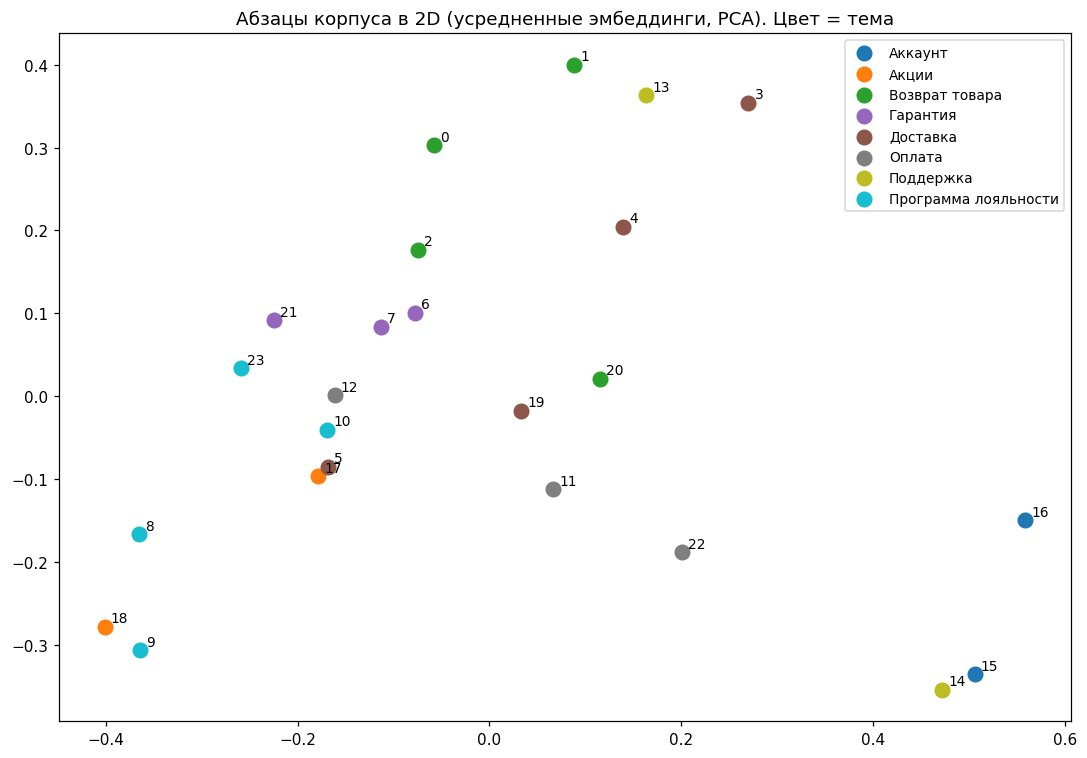

In [ ]:
from sklearn.decomposition import PCA

xy = PCA(n_components=2, random_state=0).fit_transform(D)

plt.figure(figsize=(10, 7))
uniq = sorted(set(topics))
cmap = plt.cm.tab10(np.linspace(0, 1, len(uniq)))
col = {g: cmap[i] for i, g in enumerate(uniq)}
for g in uniq:
    idx = [i for i, t in enumerate(topics) if t == g]
    plt.scatter(xy[idx, 0], xy[idx, 1], color=col[g], label=g, s=90)
for i in range(len(texts)):
    plt.annotate(str(corpus[i]["id"]), (xy[i, 0], xy[i, 1]), fontsize=9, xytext=(4, 3), textcoords="offset points")
plt.legend(fontsize=9, loc="best")
plt.title("Абзацы корпуса в 2D (усредненные эмбеддинги, PCA). Цвет = тема")
plt.tight_layout()
plt.show()

**На подумать**

- Видны ли на графике группы абзацев одной темы? Если да, насколько хорошо они отделены друг от друга?
- Есть ли абзацы, которые оказались "не на своем месте" - далеко от остальных текстов своей темы или рядом с другой темой? Что может объяснить такие случаи?

**Возможный ход рассуждений**

Если абзацы одной темы естественным образом группируются в 2D, это косвенно говорит о том, что эмбеддинги действительно отражают тематическую структуру корпуса. Но сама визуализация - лишь способ посмотреть на данные. PCA сжимает 300 измерений до двух, поэтому часть информации неизбежно теряется, а расстояния на графике нельзя воспринимать как точную меру сходства. Для количественной оценки нужно считать метрики в исходном пространстве.

## Итоги

- **Близость векторов измеряют косинусным сходством, а не совпадением слов.** "Похожесть" в векторном пространстве определяется направлением векторов. При этом высокий косинус не означает синонимию: антонимы вроде "хороший" и "плохой" тоже могут быть близкими, поскольку эмбеддинги отражают контексты употребления, а не словарные значения.

- **Аналогии отражают линейные закономерности в пространстве, но работают лишь частично.** Поэтому аналогии полезнее рассматривать как **intrinsic-оценку качества эмбеддингов**, а не как доказательство того, что модель "понимает" язык.

* **Визуализация помогает сформировать интуицию, но не заменяет количественную оценку.** PCA дает грубое представление о структуре данных, сохраняя направления наибольшей дисперсии. t-SNE хорошо показывает локальное соседство и часто делает кластеры визуально заметнее, но расстояния между кластерами и их размеры нельзя интерпретировать напрямую. Для количественных выводов используйте исходное пространство, а 2D-визуализацию - чтобы замечать кластеры, выбросы и возможные артефакты.

* **Различайте представление слова и представление документа.** BoW/TF-IDF описывают текст через слова и хорошо работают при лексических совпадениях. Усредненные эмбеддинги позволяют учитывать семантическое сходство и находить синонимы и перефразировки, но при усреднении теряют порядок слов и наследуют ограничения исходной модели. Универсально лучшего представления нет - выбор зависит от задачи, данных и требований к интерпретируемости.

* **Ограничения статических эмбеддингов определяют дальнейшее развитие подходов.** Один вектор на все значения слова плохо работает с многозначностью, а отсутствие представления для неизвестных слов создает проблему OOV. Эти ограничения мотивируют появление следующих подходов: FastText использует информацию о частях слова для работы с OOV, а контекстные представления позволяют учитывать значение слова в конкретном контексте, что приводит нас к моделям вроде BERT, о которых мы поговорим далее в курсе.


## Вопросы для рефлексии



1. Почему для поиска похожих слов часто используют косинусную близость, а не скалярное произведение или евклидово расстояние? Какие свойства этих метрик важны именно для сравнения эмбеддингов?



2. Приведите пример задачи, где близость между "хороший" и "плохой" может быть полезна, и задачи, где она, наоборот, приведет к ошибкам. Объясните, от чего зависит полезность такой близости.



3. В семантическом поиске по нашему корпусу после одинаковой лемматизации оба подхода (TF-IDF и усредненные эмбеддинги) нашли правильную тему, но эмбеддинги дали заметно более высокую абсолютную близость. Объясните механизм этого расхождения через тезисы конспекта: что именно сравнивает TF-IDF и что добавляют эмбеддинги?



4. Вам дали новый домен с редкими терминами, неизвестными словами и опечатками. Какой тип представления вы попробуете первым и почему? Какие свойства выбранного подхода должны помочь в этой ситуации?

